# Excess heat factor

In [1]:
import earthkit.data as ekd
from earthkit.meteo.thermo import excess_heat
from earthkit.plots.plottypes.statistics import bandplot

import numpy as np
import matplotlib.pyplot as plt

## Temperature timeseries: ERA5-Land, Paris

In [2]:
data = ekd.from_source("cds", dataset="reanalysis-era5-land-timeseries", request={
    "variable": ["2m_temperature"],
    "location": {"longitude": 2.4, "latitude": 48.9},
    "date": ["1950-01-02/2026-03-06"],
    "data_format": "netcdf"
})

In [3]:
da = data.to_xarray()["t2m"].compute()
da

<xarray.DataArray 't2m' (valid_time: 667752)> Size: 3MB
array([270.80234, 270.65332, 270.5417 , ..., 284.00504, 282.8971 ,
       282.02277], shape=(667752,), dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 5MB 1950-01-02 ... 2026-03-06T23:...
    latitude    float64 8B 48.9
    longitude   float64 8B 2.4
Attributes: (12/30)
    GRIB_NV:                                  0
    GRIB_Nx:                                  3600
    GRIB_Ny:                                  1801
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           t2m
    GRIB_dataType:                            fc
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               K
    long_name:                                2 metre temperature
    standard_name:                            unknown
    units:                                    K

In [4]:
reference_period = {"valid_time": slice("1970-01-01", "1999-12-31")}

## Daily mean temperature

In [5]:
dmt = excess_heat.daily_mean_temperature(da, day_start=9, time_shift=-1)

## Excess heat

In [6]:
dmt_q95 = dmt.sel(reference_period).quantile(0.95).drop_vars("quantile")
dmt_q95

<xarray.DataArray 'dmt' ()> Size: 8B
array(293.85665283)

In [29]:
ehi_sig = excess_heat.significance_index(dmt, threshold=dmt_q95)
ehi_accl = excess_heat.acclimatisation_index(dmt)

exhf = excess_heat.excess_heat_factor(ehi_sig, ehi_accl, nonnegative=True).compute()

In [32]:
exhf_q85 = exhf[exhf > 0].sel(reference_period).quantile(0.85)#.drop_vars("quantile")
hsev = excess_heat.heatwave_severity(exhf, threshold=exhf_q85)

<BarContainer object of 77 artists>

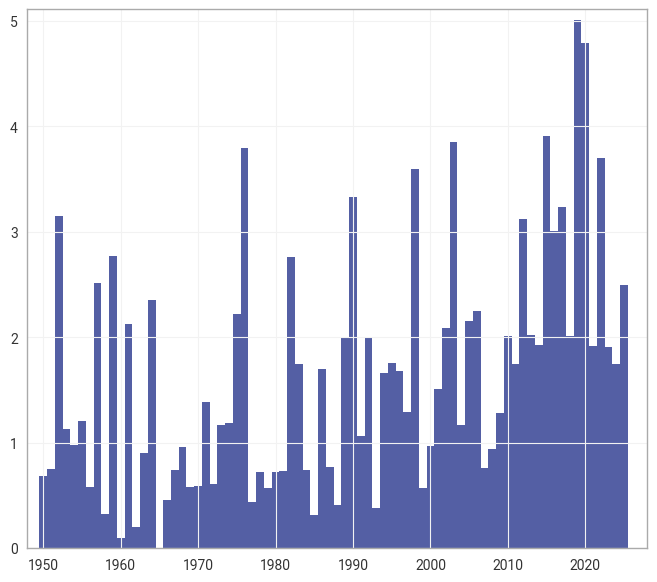

In [51]:
hsev_max_year = hsev.groupby("valid_time.year").max()
plt.bar(hsev_max_year["year"], hsev_max_year, width=1)

## Excess cold

In [10]:
dmt_q05 = dmt.sel(reference_period).quantile(0.05).drop_vars("quantile")
dmt_q05

<xarray.DataArray 'dmt' ()> Size: 8B
array(273.69984741)

In [11]:
ehi_sig = excess_heat.significance_index(dmt, threshold=dmt_q05)
ehi_accl = excess_heat.acclimatisation_index(dmt)

excf = excess_heat.excess_cold_factor(ehi_sig, ehi_accl, nonpositive=True)

## Visualise

In [8]:
exhf_qs = exhf.groupby("valid_time.dayofyear").quantile([0.0, 0.95, 0.975, 1.0])
exhf_2003 = exhf.sel({"valid_time": "2003"})

In [12]:
excf_qs = excf.groupby("valid_time.dayofyear").quantile([0.0, 0.025, 0.05, 1.0])
excf_2003 = excf.sel({"valid_time": "2003"})

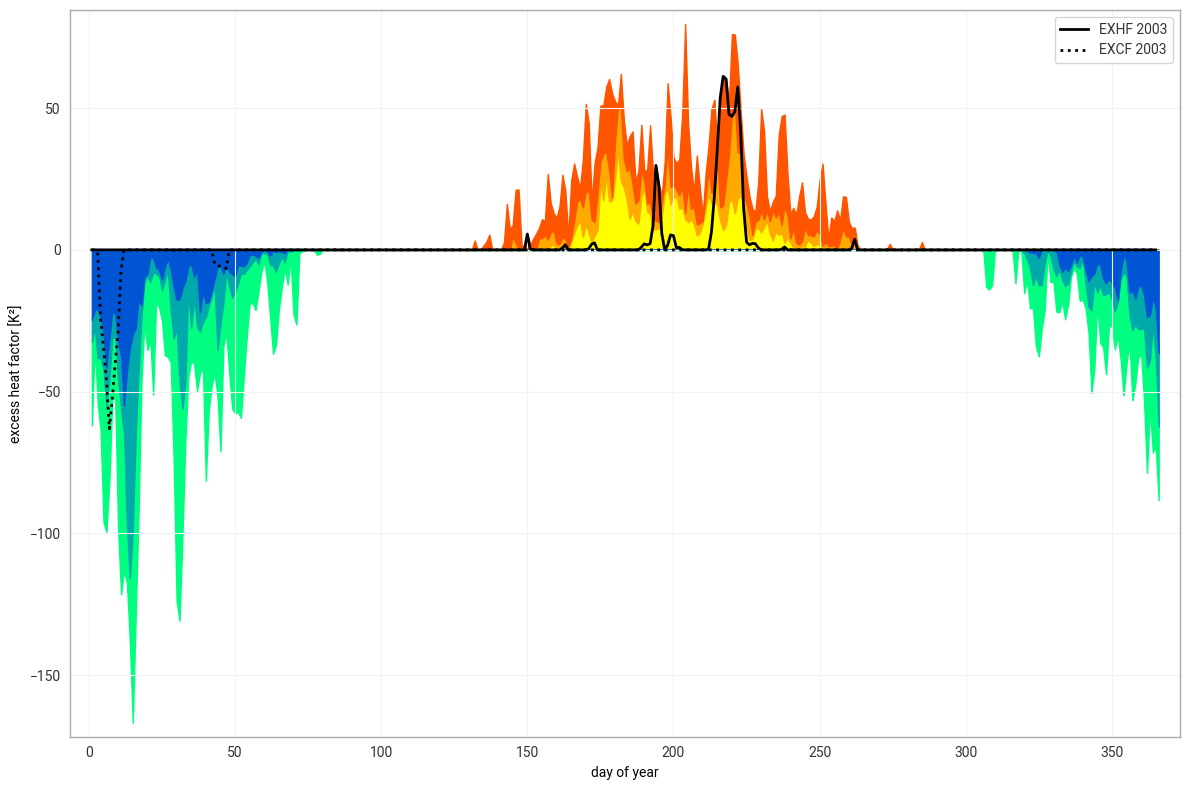

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Statistics: quantiles
band_colors = plt.get_cmap("autumn_r")(np.linspace(0, 1, exhf_qs["quantile"].size))
bandplot(ax, exhf_qs["dayofyear"], exhf_qs.T, colors=band_colors)

# Statistics: quantiles
band_colors = plt.get_cmap("winter_r")(np.linspace(0, 1, excf_qs["quantile"].size))
bandplot(ax, excf_qs["dayofyear"], excf_qs.T, colors=band_colors)

# 2003
ax.plot(exhf_2003["valid_time"].dt.dayofyear, exhf_2003, color="k", linestyle="-", linewidth=2, label="EXHF 2003")
ax.plot(excf_2003["valid_time"].dt.dayofyear, excf_2003, color="k", linestyle=":", linewidth=2, label="EXCF 2003")
ax.legend()

ax.set_xlabel("day of year")
ax.set_ylabel("excess heat factor [K²]")

fig.tight_layout()